# Setup

## Dependency Installation



*   Langraph
*   langchain: openai, community
*   duckduckgo
*   chromadb for the text embeddings



In [ ]:
!pip install langgraph langchain-openai # installing langraph
!pip install  langchain-community # install langchain community
!pip install duckduckgo-search # install duckduckgo search
!pip install ddgs # duckduckgo needed package
!pip install chromadb # text embeddings
!pip install pdfminer.six==20231228
!pip install unstructured
!pip install xlsxwriter
!pip install OpenAI

## Create environment



*   Get API key
*   Create an enum for diffrent models
*   Create ChatOpenAI for openrouter
*   Test Connection through llm.invoke



In [ ]:
from google.colab import userdata
_api_key = userdata.get('OPENROUTER_API_KEY')
# don't leak my API key it has limit of 2 dollars

In [ ]:
from enum import Enum

# enum for diffrent llm models

class MODELS(Enum):
    CLAUDE_4_5 = "claude-sonnet-4.5"
    GEMINI_3_FLASH = "gemini-3-flash-preview"
    GEMINI_2_5_FLASH = "gemini-2.5-flash"
    Grok_Code_Fast = "grok-code-fast-1"
    Grok_4_1 = "grok-4.1-fast"
    DeepSeek_V3 = "deepseek-v3.2"
    GPT_4o_mini = "gpt-4o-mini"
    GPT_5_2 = "gpt-5.2"
    GPT_OSS = "gpt-oss-120b"

    TEXT_EMBEDDING_SMALL = "text-embedding-3-small"
    TEXT_EMBEDDING_LARGE = "text-embedding-3-large"
    TEXT_EMBEDDING_LLAMA = "hermes-2-pro-llama-3-8b-embeddings"
    EMBEDDING = "bge-large-en-v1.5"

    def __str__(self):
        return self.value

    def __repr__(self):
        return self.value

In [ ]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
# setting up the llm with a open router api key

Open_Router_URL: str = "https://openrouter.ai/api/v1"

llm = ChatOpenAI(api_key=_api_key,
                 model=MODELS.GPT_4o_mini.value, # from the MODELS enum
                 base_url=Open_Router_URL,
                 temperature=0, # temperature can be from 0.0 to 1.0, higher the value, the more the variation
                 )

Embeddings = OpenAIEmbeddings(api_key=_api_key,
                                    model=MODELS.TEXT_EMBEDDING_SMALL.value,
                                    base_url=Open_Router_URL,
                                    )

## Quick Test

In [ ]:
from langchain.messages import SystemMessage, HumanMessage, AIMessage
# quick test
# docs https://docs.langchain.com/oss/python/langchain/messages

system_msg = SystemMessage("You are a helpful coding assistant.")

messages = [
    system_msg,
    HumanMessage("whats up my chatbot from google colab")
]

message: AIMessage = llm.invoke(messages) # returns AIMessage
message.content

"Hello! I'm here to help you with any questions or tasks you have related to coding, data analysis, or anything else you might need assistance with in Google Colab or beyond. What can I help you with today?"

# Creating tools

## Creating a Directory Tool

In [ ]:
from langchain_community.agent_toolkits.file_management.toolkit import FileManagementToolkit
import os

input_dir = "input_dir"
os.makedirs(input_dir, exist_ok=True)

output_file_management_tools = FileManagementToolkit(
    root_dir=input_dir,
    selected_tools=["read_file", "write_file", "list_directory"] # Select only necessary tools
).get_tools() # note this is a list of tools


### Testing Directory Tool

In [ ]:
from langchain.agents import create_agent

agent_executor = create_agent(llm, output_file_management_tools)

query = "Create a file named 'hello.txt' with the text 'Hello from LangChain!', then read it back to confirm."
response = agent_executor.invoke({"messages": [("user", query)]})

# Print the agent's final message
print(response["messages"][-1].content)


The file 'hello.txt' has been created with the text 'Hello from LangChain!', and it has been read back successfully, confirming the content.


In [ ]:
import shutil

# deleting output contents

def delete_contents(directory: str):
  if os.path.exists(directory) and os.path.isdir(directory):
    shutil.rmtree(directory)
  os.mkdir(directory)

delete_contents(input_dir)

## Creating Search Tool

In [ ]:
from langchain_community.tools import DuckDuckGoSearchRun

# Initialize the tool
search_tool = DuckDuckGoSearchRun()

### Testing Search Tool

In [ ]:
from langchain.agents import create_agent

agent_executor = create_agent(llm, [search_tool])

query = "Tell me about Florida PolyTech University"
response = agent_executor.invoke({"messages": [("user", query)]})

# Print the agent's final message
print(response["messages"][-1].content)

Florida Polytechnic University is a public institution located in Lakeland, Florida, that focuses exclusively on undergraduate and graduate programs in science, technology, engineering, and mathematics (STEM). The university is known for its small class sizes, which facilitate personalized attention from professors, fostering a collaborative learning environment.

Florida Poly offers ten undergraduate and four master's degree programs, emphasizing STEM education and research. The faculty are noted for their passion and support, often providing individual help to students. The university's online catalog includes detailed information on course descriptions, requirements, and plans of study for both undergraduate and graduate programs.


## Creating PDF Tool

In [ ]:
#PDF tool begining
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pathlib import Path
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_classic.chains import RetrievalQA
from langchain.tools import tool
import os


if (not any(Path(input_dir).iterdir())):
  raise Exception("You need to put some PDFs in the user directory")

documents = []


for file_path in Path(input_dir).glob('*.pdf'):
    loader = PyPDFLoader(str(file_path))
    documents.extend(loader.load())


text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    length_function=len,
)

chunks = text_splitter.split_documents(documents)

vector_store = Chroma.from_documents(chunks, Embeddings)

retriever = vector_store.as_retriever()

@tool("pdf_tool")
def pdf_tool(input: str) -> str:
  '''Request a summary of information from a PDF with the directory

  ARGS:
    input: Information request to the PDF list

  '''

  qa_chain = RetrievalQA.from_chain_type(
      llm,
      chain_type="stuff",
      retriever=retriever
  )

  query = input
  response = qa_chain.invoke({"query": query})
  return response["result"]

### Testing PDF Tool

In [ ]:
#Testing Tool


qa_chain = RetrievalQA.from_chain_type(
    llm,
    chain_type="stuff",
    retriever=retriever
)

query = "What is the main topic of the documents?"
response = qa_chain.invoke({"query": query})
print(response["result"])

The main topic of the documents is software engineering, specifically focusing on various software development methodologies and models, such as the Waterfall model, V-Model, Spiral model, Scrum, and Kanban. The documents outline assignments related to these topics, requiring students to discuss their advantages, limitations, and applicability in different scenarios.


## Creating an Excel Tool

example data structure

- title
- start date
- due date
- requirements
- priority level
- amount of days needed
- notes

In [ ]:
import xlsxwriter
from datetime import datetime
from langchain.tools import tool
from pydantic import BaseModel, Field
from typing import List


class GanttTask(BaseModel):
    title: str = Field(description="The name of the task")
    start_date: str = Field(description="Start date in YYYY-MM-DD format")
    due_date: str = Field(description="End date in YYYY-MM-DD format")
    requirements: str = Field(description="List of prerequisites or resources")
    priority: int = Field(description="Priority level (e.g., 1 for high, 3 for low)")
    days_needed: int = Field(description="Total duration in days")
    notes: str = Field(description="Additional context or comments")

class GanttInput(BaseModel):
    tasks: List[GanttTask] = Field(description="A list of tasks to be plotted on the Gantt chart")


@tool("test_tool", args_schema=GanttInput)
def test_tool(tasks: List[GanttTask]):
    """
    Useful for visualizing project timelines and schedules.
    Input should be a list of tasks with dates and requirements.
    """
    return create_gantt_chart_tool(tasks)

def create_gantt_chart_tool(tasks: List[GanttTask]):
    """Creates a Gantt chart in an Excel file from a list of tasks."""
    # Convert Pydantic objects back into the tuple format for the main functions
    formatted_data = [
        (t.title, t.start_date, t.due_date, t.requirements, t.priority, t.days_needed, t.notes)
        for t in tasks
    ]

    return create_gantt_chart(formatted_data)

def create_gantt_chart(data):
  workbook  = xlsxwriter.Workbook('Gantt_Chart.xlsx')
  worksheet = workbook.add_worksheet('Project Plan')

  date_format = workbook.add_format({'num_format': 'yyyy-mm-dd'})

  headers = ['Title', 'Start Date', 'Due Date', 'Requirements', 'Priority', 'Days', 'notes']
  worksheet.write_row('A1', headers)

  for row, (title, start_str, due_str, req, prio, days, notes) in enumerate(data, start=1):
      start_date = datetime.strptime(start_str, "%Y-%m-%d")
      due_date = datetime.strptime(due_str, "%Y-%m-%d")

      worksheet.write(row, 0, title)
      worksheet.write_datetime(row, 1, start_date, date_format)
      worksheet.write_datetime(row, 2, due_date, date_format)
      worksheet.write(row, 3, req)
      worksheet.write(row, 4, prio)
      worksheet.write(row, 5, days)
      worksheet.write(row, 6, notes)

  chart = workbook.add_chart({'type': 'bar', 'subtype': 'stacked'})

  chart.add_series({
      'name':       'Start Date',
      'categories': ['Project Plan', 1, 0, len(data), 0], # Task Titles
      'values':     ['Project Plan', 1, 1, len(data), 1], # Start Dates
      'fill':       {'none': True},                      # Make it invisible
  })

  chart.add_series({
      'name':       'Days to Complete',
      'categories': ['Project Plan', 1, 0, len(data), 0],
      'values':     ['Project Plan', 1, 5, len(data), 5], # Duration (Days)
      'fill':       {'color': '#4B8BBE'},                # Project color
  })

  chart.set_x_axis({'name': 'Timeline', 'num_font': {'rotation': -45}})
  chart.set_title({'name': 'Project Schedule'})
  chart.set_legend({'none': True})

  chart.set_y_axis({'reverse': True})

  worksheet.insert_chart('H2', chart)

  workbook.close()

### Testing Excel Tool

In [ ]:
data = [
    ('Task 1', "2026-05-05", "2026-05-08", 'Requirements A', 1, 3, "test notes"),
    ('Task 2', "2026-05-07", "2026-05-15", 'Requirements B', 2, 8, "test notes"),
    ('Task 3', "2026-05-10", "2026-05-20", 'Requirements C', 1, 10, "test notes"),
]

create_gantt_chart(data)

In [ ]:
from langchain.agents import create_agent

agent_executor = create_agent(llm, [create_gantt_chart_tool])

query = "For testing purposes create call the gantt chart tool, and make up 5 entries."
response = agent_executor.invoke({"messages": [("user", query)]})

# Print the agent's final message
print(response["messages"][-1].content)

The Gantt chart tool has been called successfully with the test entries. If you need any further actions or modifications, please let me know!


# Possible Graph Representation
Goal: Create a structured study plan in a spreadsheet.

Agent Approach: Plan-and-Execute.

Tools chosen: web search, file management, pdf analyzer, excel.

Environment files: Syllabus.txt, Rubric.txt, faq.txt, 1 or more Assignments.pdf.


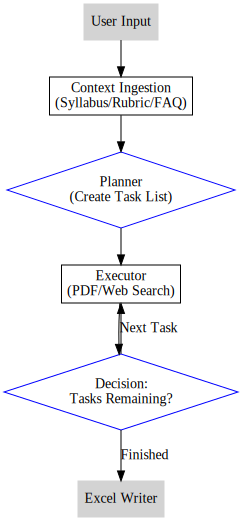

In [ ]:
import graphviz
import os

dot = graphviz.Digraph(comment='Study Planner Agent', format='svg')

# Nodes
dot.node('Start', 'User Input', shape='box', style='filled', color='lightgrey')
dot.node('Parse', 'Context Ingestion\n(Syllabus/Rubric/FAQ)', shape='box')
dot.node('Planner', 'Planner\n(Create Task List)', shape='diamond', color='blue')
dot.node('Exec', 'Executor\n(PDF/Web Search)', shape='box')
dot.node('Check', 'Decision:\nTasks Remaining?', shape='diamond', color='blue')
dot.node('Excel', 'Excel Writer', shape='box', style='filled', color='lightgrey')

# Edges
dot.edge('Start', 'Parse')
dot.edge('Parse', 'Planner')
dot.edge('Planner', 'Exec')
dot.edge('Exec', 'Check')
dot.edge('Check', 'Exec', label='Next Task')
dot.edge('Check', 'Excel', label='Finished')

graph_dir = "graph"
os.makedirs(graph_dir, exist_ok=True)

dot.render(f'{graph_dir}/Example Graph', cleanup=True)
dot

## Explaination of the Graph

- Context Ingestion: takes in a the required files and addes it to the global context
- Planner: Outputs a list of json tasks/assignments
- Loop of executor and Decision: check the condition are there any tasks left, finish or continue the loop. Each loop is a state of memory that is accessed at the end
- Excel writer: From each of the states of memory, write a summary into an excel file

# Creating Agent

## Define Agent State

In [ ]:
from typing import Annotated, TypedDict, List, Dict, Literal, Any, Optional
from langgraph.graph.message import add_messages
from pathlib import Path
from langchain_community.vectorstores import Chroma


class PlanTask(TypedDict):
    title: str
    assignment_ref: Path
    focus_area: str
    start_date: str
    due_date: str
    notes: str

class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

    rubric_files: List[Path]
    assignments: List[Path]
    summary: str

    plan: List[PlanTask]     # The sequence of study tasks
    task_results: List[GanttTask] # Store results
    current_task_idx: int # index of task_results


## Define Agent Nodes

- Gather/Parse: Sets the stage
- Planner: Breaks the syllabus into a list of "Gantt-friendly" steps
- Executor: The workhorse. It loops through the plan, using your tools (web search/PDF analyzer) to fill out the GanttTask details for each step
- Excel Writer: The finisher

In [ ]:
# based on https://deepcharts.substack.com/p/build-a-plan-and-execute-ai-agent


import json, re
from datetime import datetime, timedelta
from pathlib import Path

def gather(state: AgentState):
    """
    Gather files from input directory and categorize them.
    This acts as the perception step of the agent.
    """

    rubric_files = []
    assignment_files = []
    input_path = Path(input_dir)

    for file in input_path.iterdir():
        if file.is_file():
            name = file.name.lower()

            if "rubric" in name:
                rubric_files.append(file)

            elif "sylla" in name:
                rubric_files.append(file)

            elif "faq" in name:
                rubric_files.append(file)

            else:
                assignment_files.append(file)

    print(f"  Rubric files found: {len(rubric_files)}")
    print(f"  Assignment files found: {len(assignment_files)}")
    return {
        "rubric_files": rubric_files,
        "assignments": assignment_files,
        "current_task_idx": 0
    }

def parse(state: AgentState):
    """
    Loads all rubric PDFs into a Chroma vector store and asks the LLM to
    produce a summary requirements.
    """
    print("\n[PARSE NODE]")
    rubric_files = state["rubric_files"]

    if not rubric_files:
        print("  No rubric files found — skipping parse.")
        return {"summary": "No rubric files were found."}


    documents = []
    for file_path in rubric_files:
        loader = PyPDFLoader(str(file_path))
        documents.extend(loader.load())

    splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
    chunks = splitter.split_documents(documents)


    vector_store = Chroma.from_documents(chunks, Embeddings, collection_name="rubrics")
    retriever = vector_store.as_retriever(search_kwargs={"k": 8})

    qa_chain = RetrievalQA.from_chain_type(llm, chain_type="stuff", retriever=retriever)

    query = (
        "Summarise all grading criteria, key requirements, deadlines, and point "
        "breakdowns found across these rubric documents. Be thorough."
    )
    response = qa_chain.invoke({"query": query})
    summary = response["result"]

    print(f"  Summary length: {len(summary)} chars")
    return {"summary": summary}

def planner(state: AgentState):
    """
    Uses the rubric summary and list of assignment filenames to produce a
    structured list of PlanTask items.
    """
    print("\n[PLANNER NODE]")

    summary    = state["summary"]
    assignments = state["assignments"]

    assignment_names = "\n".join(
        f"- {a.name} (path: {str(a)})" for a in assignments
    )

    user_preferences = state["messages"][0].content

    prompt = f"""
    You are scheduling assistant.

    RUBRIC SUMMARY:
    {summary}

    ASSIGNMENT FILES:
    {assignment_names}

    For each assignment file, create a schedule entry. Return a JSON array where
    each element has exactly these keys:
      - "title"          : short human-readable name for the task
      - "assignment_ref" : the file path string from the list above
      - "focus_area"     : the main grading criterion this assignment targets
      - "start_date"     : suggested start date in YYYY-MM-DD (assume today is the start)
      - "due_date"       : suggested due date in YYYY-MM-DD based on rubric deadlines,
                           if not specified make one up
      - "notes"          : any important reminders from the rubric

    Return ONLY a valid JSON array, no commentary.

    USER PREFERENCES:
    {user_preferences}
    """
    response = llm.invoke(prompt)

    match = re.search(r"\[.*\]", response.content, re.DOTALL)
    raw_plan = json.loads(match.group()) if match else []

    plan: List[PlanTask] = []
    for item in raw_plan:
        item["assignment_ref"] = Path(item["assignment_ref"])
        plan.append(item)

    print(f"Plan items created: {len(plan)}")
    for index, plan_item in enumerate(plan):
        print(f"  {index + 1}. {plan_item['title']}")
    return {"plan": plan}

def executor(state: AgentState):

  """
  This processes one plan task by turing it into subtasks and generating GnattTask items.
  Then it updates the current_task_idx in the AgentState.
  """

  print("\n[EXECUTOR NODE]")
  idx          = state["current_task_idx"]
  current_item = state["plan"][idx]
  file_path    = current_item["assignment_ref"]

  print(f"  Processing task {idx + 1}: {current_item['title']}")

  documents = []
  if Path(file_path).exists():
      loader = PyPDFLoader(str(file_path))
      documents.extend(loader.load())
  else:
      print(f"  WARNING: {file_path} not found — using plan metadata only.")

  subtasks_json = None

  if documents:
      splitter     = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
      chunks       = splitter.split_documents(documents)
      vector_store = Chroma.from_documents(
          chunks, Embeddings,
          collection_name=f"assignment_{idx}"
      )
      retriever = vector_store.as_retriever(search_kwargs={"k": 5})
      qa_chain  = RetrievalQA.from_chain_type(llm, chain_type="stuff", retriever=retriever)

      user_preferences = state["messages"][0].content
      response = qa_chain.invoke({
          "query": (
              f"Break this assignment into 2-8 concrete subtasks a student should "
              f"complete between {current_item['start_date']} and {current_item['due_date']}. "
              "Return ONLY a JSON array where each element has:\n"
              '  - "title"       : short subtask name\n'
              '  - "requirements": what needs to be done\n'
              '  - "days_needed" : integer estimate of days required\n'
              '  - "notes"       : any tips or reminders\n'
              "No commentary, just the JSON array."
              f"USER PREFERENCES: {user_preferences}"
          )
      })

      match = re.search(r"\[.*\]", response["result"], re.DOTALL)
      if match:
          subtasks_json = json.loads(match.group())


  new_gantt_tasks = []
  current_start = datetime.strptime(current_item["start_date"], "%Y-%m-%d")
  final_due     = datetime.strptime(current_item["due_date"],   "%Y-%m-%d")
  total_days    = max((final_due - current_start).days, 1)

  # Scale each subtask's days proportionally so they all fit before due_date
  raw_days  = [max(s.get("days_needed", 1), 1) for s in subtasks_json]
  total_raw = sum(raw_days)

  for i, subtask in enumerate(subtasks_json):
      scaled_days = max(round(raw_days[i] / total_raw * total_days), 1)
      subtask_end = current_start + timedelta(days=scaled_days)

      if i == len(subtasks_json) - 1:
          subtask_end = final_due

      new_gantt_tasks.append(GanttTask(
          title=        f"{current_item['title']} — {subtask['title']}",
          start_date=   current_start.strftime("%Y-%m-%d"),
          due_date=     subtask_end.strftime("%Y-%m-%d"),
          requirements= subtask["requirements"],
          priority=     idx + 1,
          days_needed=  scaled_days,
          notes=        subtask.get("notes", ""),
      ))

      current_start = subtask_end  # next subtask starts where this one ends

  updated_results = state.get("task_results", []) + new_gantt_tasks
  return {
      "task_results":     updated_results,
      "current_task_idx": idx + 1,
  }

def should_continue(state: AgentState) -> Literal["Executor", "Excel Writer"]:
  print("\n[CONDITIONAL NEXT TASK NODE]")

  if state["current_task_idx"] < len(state["plan"]):
        return "Executor"
  return "Excel Writer"

def excel_writer(state: AgentState):
  print("\n[EXCEL WRITER NODE]")

  # uses the GanttTasks to create an excel spreadsheet with a chart

  create_gantt_chart_tool(state["task_results"])

  print("Gnatt Chart was created. End of agent.")
  return

## Build LLM Graph

In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver() #initializes long term memory

graph_builder = StateGraph(AgentState)

graph_builder.add_node("Gather",       gather)
graph_builder.add_node("Parse",        parse)
graph_builder.add_node("Planner",      planner)
graph_builder.add_node("Executor",     executor)
graph_builder.add_node("Excel Writer", excel_writer)


graph_builder.add_edge(START,      "Gather")
graph_builder.add_edge("Gather",   "Parse")
graph_builder.add_edge("Parse",    "Planner")
graph_builder.add_edge("Planner",  "Executor")

graph_builder.add_conditional_edges("Executor", should_continue)

graph_builder.add_edge("Excel Writer", END)

graph = graph_builder.compile(checkpointer=memory)

# Using The Agent

## Graph Visualisation

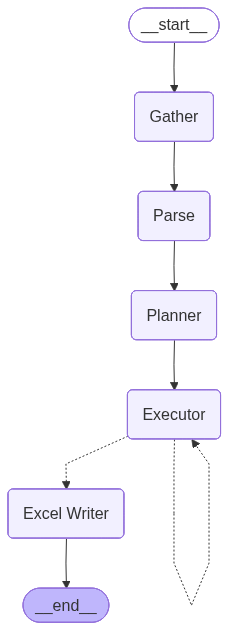

In [ ]:
from IPython.display import Image, display
import os

graph_dir = "graph"
os.makedirs(graph_dir, exist_ok=True)
image_data = graph.get_graph().draw_mermaid_png()
display(Image(image_data))

with open(f"{graph_dir}/LanGraph Visual.png", mode="wb") as f:
    f.write(image_data)

## Graph LLM input/output Loop

In [ ]:
# Function to handle input and responses
def stream_graph_updates(user_input: str, thread_id: str = "student_session_1"):

    role = {""}
    config = {"configurable": {"thread_id": thread_id}} # dictates which long-term memory thread to load or save

    inputs = {"messages": [("user", user_input)]} # mapping the input directly to the messages state key

    message = graph.invoke(inputs, config=config)

    return message["messages"][-1].content

In [ ]:
print("Welcome to the LangGraph chatbot! Type 'quit', 'exit', or 'q' to stop.")

current_thread = "study_plan_1" # can change this ID to start a new memory state for a new task


user_input =  input("User: ")

message = stream_graph_updates(user_input, thread_id=current_thread)
print("Finished output")


Welcome to the LangGraph chatbot! Type 'quit', 'exit', or 'q' to stop.
User: Please create a schedule for me use some emojis
  Rubric files found: 1
  Assignment files found: 3

[PARSE NODE]
  Summary length: 2380 chars

[PLANNER NODE]
Plan items created: 3
  1. Assignment 1 📄
  2. Assignment 2 📄
  3. Final Project 📊

[EXECUTOR NODE]
  Processing task 1: Assignment 1 📄

[CONDITIONAL NEXT TASK NODE]

[EXECUTOR NODE]
  Processing task 2: Assignment 2 📄

[CONDITIONAL NEXT TASK NODE]

[EXECUTOR NODE]
  Processing task 3: Final Project 📊

[CONDITIONAL NEXT TASK NODE]

[EXCEL WRITER NODE]
Gnatt Chart was created. End of agent.
Agent:  Please create a schedule for me use some emojis


KeyboardInterrupt: Interrupted by user